#**The Sugar Trap Market Gap Analysis**

## **PART 1: Dataset Loading & Libraries**

###1.Useful Libraries to be used:

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from google.colab import files
import gspread
from gspread_dataframe import set_with_dataframe
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

###2.Loading and Analyzing Open Food Fact dataset

In [26]:
# Getting dataset Link
URL = "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"

# Loading Dataset as "df"
df = pd.read_csv(URL, sep='\t', nrows=500_000, low_memory=False)

# Allow the notebook to view all columns
pd.set_option('display.max_columns', None)

In [27]:
# View first 5  of the food dataset
df.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,product_name,abbreviated_product_name,generic_name,quantity,packaging,packaging_tags,packaging_en,packaging_text,brands,brands_tags,brands_en,categories,categories_tags,categories_en,origins,origins_tags,origins_en,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_en,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_en,ingredients_text,ingredients_tags,ingredients_analysis_tags,allergens,allergens_en,traces,traces_tags,traces_en,serving_size,serving_quantity,no_nutrition_data,additives_n,additives,additives_tags,additives_en,nutriscore_score,nutriscore_grade,nova_group,pnns_groups_1,pnns_groups_2,food_groups,food_groups_tags,food_groups_en,states,states_tags,states_en,brand_owner,environmental_score_score,environmental_score_grade,nutrient_levels_tags,product_quantity,owner,data_quality_errors_tags,unique_scans_n,popularity_tags,completeness,last_image_t,last_image_datetime,main_category,main_category_en,image_url,image_small_url,image_ingredients_url,image_ingredients_small_url,image_nutrition_url,image_nutrition_small_url,energy-kj_100g,energy-kcal_100g,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,unsaturated-fat_100g,monounsaturated-fat_100g,omega-9-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,omega-6-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,added-sugars_100g,sucrose_100g,glucose_100g,fructose_100g,galactose_100g,lactose_100g,maltose_100g,maltodextrins_100g,psicose_100g,starch_100g,polyols_100g,erythritol_100g,isomalt_100g,maltitol_100g,sorbitol_100g,fiber_100g,soluble-fiber_100g,polydextrose_100g,insoluble-fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,added-salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,methylsulfonylmethane_100g,hydroxymethylbutyrate_100g,ph_100g,fruits-vegetables-legumes_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,glycemic-index_100g,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1.740205e+09,2025-02-22T06:23:42Z,Limonade artisanale a la rose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en:fr,en:france,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,NaN,unknown,unknown,NaN,NaN,NaN,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","To be completed,Nutrition facts to be complete...",NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,0.1625,1.733085e+09,202

In [28]:
print(f"The dataset consist of {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset consist of 500000 rows and 211 columns.


In [29]:
# Further information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Columns: 211 entries, code to water_100g
dtypes: float64(136), int64(3), object(72)
memory usage: 804.9+ MB


*The Food Fact Dataset has 211 columns and has been set to use first 500,000 rows for the moment.*

## **PART 2: User Stories & Acceptance Criteria**

### **Story 1: Data Ingestion & "The Clean Up"**

In [30]:
# Selecting few columns to use, dataframe named "food_df"
food_df = df[['product_name','categories_tags','sugars_100g',
                          'proteins_100g','fat_100g','fiber_100g', 'ingredients_text']]

food_df.head()

,product_name,categories_tags,sugars_100g,proteins_100g,fat_100g,fiber_100g,ingredients_text
0,Limonade artisanale a la rose,NaN,NaN,NaN,NaN,NaN,NaN
1,M&amp;M white,NaN,NaN,NaN,NaN,NaN,"Weizenmehl, Rapsöl, Speisesalz, 1,7% Meersalz,..."
2,Chocolate n3,NaN,NaN,NaN,NaN,NaN,NaN
3,Pâte de fruits,NaN,NaN,NaN,NaN,NaN,NaN
4,Paleta gran reserva - Sierra nevada-,"en:beverages-and-beverages-preparations,en:bev...",NaN,NaN,NaN,NaN,"Thiamin, Biotin, Chromium, Garcinia cambogia f..."


*As it is visible in the dataframe we have so many missing values, next step is to delete rows with missing values in empty "sugars_100g", "proteins_100g", or "product_name".*

In [31]:
# I drop rows based on 3 critical columns
food_df = food_df.dropna(subset=['product_name','sugars_100g',
                          'proteins_100g'])

# Shape of dataframe after removing some rows
food_df.shape

(109826, 7)

###Handling Outliers (nutrients > 100g/100g product)

In [32]:
# Remove Biologically impossible values among 4 nutrients columns
nutrients_columns = ['sugars_100g','proteins_100g','fat_100g','fiber_100g']

for column in nutrients_columns:
    food_df = food_df[(food_df[column] >= 0) & (food_df[column] <= 100)]

# Cleaned dataset now
print(f"Dataset now has: {len(food_df):,} rows after cleaning")

Dataset now has: 80,707 rows after cleaning


In [33]:
food_df.head()

,product_name,categories_tags,sugars_100g,proteins_100g,fat_100g,fiber_100g,ingredients_text
689,Pinto Bean,en:asian-style-ready-meal,4.900000,17.500000,10.200000,3.800000,NaN
691,Keto & GF Granola,NaN,3.225806,19.677419,54.838710,9.677419,NaN
835,Thaï Red Curry (produit préparé),NaN,1.200000,1.400000,0.600000,0.700000,NaN
840,pasta,"en:beverages-and-beverages-preparations,en:bev...",1.900000,6.700000,6.400000,0.800000,NaN
848,Dunnes Stores Irish Beef & Pork Quarter Pounders,NaN,0.521739,15.652174,11.304348,0.782609,NaN


###**Story 2: The Category Wrangler**

In [34]:
# Assign food products in categories based on keywords found in 'categories_tags'
def assign_category(tags):
    # If 'categories_tags' is missing (NaN), assign 'Other' category
    if pd.isna(tags):
        return 'Other'

    # Convert tags to lowercase for case-insensitive matching
    tags = tags.lower()

    # Check for keywords related to 'Protein Bars' category
    if any(k in tags for k in [
        'protein-bar', 'energy-bar', 'granola-bar', 'sports-nutrition',
        'protein-powder', 'meal-replacement', 'nutrition-bar'
    ]): return 'Protein Bars & Suppliments'

    # Check for keywords related to 'Confectionery' category
    if any(k in tags for k in [
        'chocolate', 'candy', 'confection', 'sweet', 'gummy',
        'marshmallow', 'caramel', 'nougat', 'lollipop', 'fudge'
    ]): return 'Confectionery'

    # Check for keywords related to 'Dairy' category
    if any(k in tags for k in [
        'dairy', 'milk', 'yogurt', 'yoghurt', 'cheese', 'butter',
        'cream', 'kefir', 'whey', 'casein', 'egg'
    ]): return 'Dairy & Eggs'

    # Check for keywords related to 'Cereals' category
    if any(k in tags for k in [
        'cereal', 'oat', 'muesli', 'porridge', 'granola',
        'rice', 'wheat', 'grain', 'quinoa', 'barley', 'corn-flour',
        'pasta', 'noodle', 'bread', 'flour'
    ]): return 'Cereals & Grains'

    # Check for keywords related to 'Beverages' category
    if any(k in tags for k in [
        'beverage', 'drink', 'juice', 'soda', 'water', 'tea',
        'coffee', 'smoothie', 'shake', 'lemonade', 'beer', 'wine',
        'spirits', 'alcohol', 'en:beverages'
    ]): return 'Beverages'

    # Check for keywords related to 'Bakery - Snacks' category
    if any(k in tags for k in [
        'biscuit', 'cookie', 'cake', 'pastry', 'muffin', 'wafer',
        'cracker', 'pretzel', 'chip', 'crisp', 'popcorn', 'snack',
        'puff', 'tortilla', 'en:biscuits', 'en:crackers'
    ]): return 'Bakery & Snacks'

    # Check for keywords related to 'Legumes - Plant proteins' category
    if any(k in tags for k in [
        'legume', 'lentil', 'bean', 'pea', 'chickpea', 'soy',
        'tofu', 'tempeh', 'edamame', 'hummus', 'pulse',
        'en:legumes', 'en:beans', 'en:lentils'
    ]): return 'Legumes & Plant Protein'

    # Check for keywords related to 'Nuts - Seeds' category
    if any(k in tags for k in [
        'nut', 'almond', 'cashew', 'walnut', 'peanut', 'seed',
        'sunflower', 'pumpkin-seed', 'chia', 'flax', 'hemp',
        'en:nuts', 'en:seeds', 'nut-butter'
    ]): return 'Nuts & Seeds'

    # Check for keywords related to 'Fruits - Vegetables' category
    if any(k in tags for k in [
        'fruit', 'vegetable', 'veggie', 'produce', 'dried-fruit',
        'raisin', 'berry', 'apple', 'banana', 'broccoli', 'spinach',
        'en:fruits', 'en:vegetables', 'en:dried-fruits'
    ]): return 'Fruits & Vegetables'

    # Check for keywords related to 'Condiments - Seasonings' category
    if any(k in tags for k in [
        'condiment', 'sauce', 'seasoning', 'spice', 'herb', 'salt',
        'pepper', 'yeast', 'vinegar', 'dressing', 'marinade',
        'en:condiments', 'en:spices', 'en:seasonings'
    ]): return 'Condiments & Seasonings'

    # Check for keywords related to 'Meat - Fish' category
    if any(k in tags for k in [
        'meat', 'chicken', 'beef', 'pork', 'fish', 'seafood',
        'salmon', 'tuna', 'turkey', 'jerky', 'en:meats', 'en:fish'
    ]): return 'Meat & Fish'

    # If no specific category matches, assign 'Other'
    return 'Other'

# Apply the 'assign_category' function to the 'categories_tags' column
# and store the results in a new column called 'primary_category' in the cleaned 'food_df' DataFrame.
food_df['primary_category'] = food_df['categories_tags'].apply(assign_category)

# coverage
food_df['primary_category'].value_counts()

,count
primary_category,
Other,41740
Cereals & Grains,12477
Dairy & Eggs,7265
Confectionery,6275
Beverages,6157
Meat & Fish,2310
Bakery & Snacks,2076
Condiments & Seasonings,1922
Protein Bars & Suppliments,214


###**Story 3: The "Nutrient Matrix" Visualization & Story 4: The Recommendation**

In [45]:
#Quadrant labeling
def label_quadrant(row):
    if row['sugars_100g'] < 10 and row['proteins_100g'] > 15:
        return 'High Protein Low Sugar (Blue Ocean)'
    elif row['sugars_100g'] >= 10 and row['proteins_100g'] > 15:
        return 'High Protein High Sugar'
    elif row['sugars_100g'] < 10 and row['proteins_100g'] <= 15:
        return 'Low Sugar Low Protein'
    else:
        return 'High Sugar Low Protein (Danger Zone)'

food_df['quadrant'] = food_df.apply(label_quadrant, axis=1)
print("quadrant added")

#Extract recommendation numbers
blue_ocean = food_df[
    (food_df['quadrant'] == 'High Protein Low Sugar (Blue Ocean)') &
    (food_df['primary_category'] != 'Other')
].copy()

best_category  = blue_ocean['primary_category'].value_counts().index[0]
target_protein = round(blue_ocean[blue_ocean['primary_category'] ==
                                  best_category]['proteins_100g'].median(), 1)
target_sugar   = round(blue_ocean[blue_ocean['primary_category'] ==
                                  best_category]['sugars_100g'].quantile(0.90), 1)

insight = (
    f"Based on the data, the biggest market opportunity is in \n"
    f"**{best_category}**, specifically targeting products with \n"
    f"{target_protein}g of protein and less than {target_sugar}g of sugar."
)

print("-" * 65)
print("SUMMARY")
print("-" * 65)
print(insight)
print("-" * 65)
print(f"\nBest category  : {best_category}")
print(f"Target protein : {target_protein}g")
print(f"Max sugar      : {target_sugar}g")

#Export for Streamlit Dashboard
scatter_df = food_df[[
    'product_name',
    'primary_category',
    'sugars_100g',
    'proteins_100g',
    'quadrant'
]].dropna().reset_index(drop=True)

scatter_df.to_csv('nutrient_matrix.csv', index=False)
print(f"\nnutrient_matrix.csv exported with {len(scatter_df):,} rows")
print(f"\nQuadrant distribution:\n{scatter_df['quadrant'].value_counts()}")

# Download the csv file
files.download('nutrient_matrix.csv')

quadrant added
-----------------------------------------------------------------
SUMMARY
-----------------------------------------------------------------
Based on the data, the biggest market opportunity is in 
**Meat & Fish**, specifically targeting products with 
20.0g of protein and less than 3.4g of sugar.
-----------------------------------------------------------------

Best category  : Meat & Fish
Target protein : 20.0g
Max sugar      : 3.4g

nutrient_matrix.csv exported with 80,707 rows

Quadrant distribution:
quadrant
Low Sugar Low Protein                   43639
High Sugar Low Protein (Danger Zone)    24775
High Protein Low Sugar (Blue Ocean)     10728
High Protein High Sugar                  1565
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###**5. Bonus User Story: The "Hidden Gem"**

In [36]:
# High Protein cluster is same as Blue Ocean where protein > 15g, sugar < 10g
# but here we focus only on ingredients_text
high_protein = food_df[
    (food_df['proteins_100g'] > 15) &
    (food_df['primary_category'] != 'Other')
].copy()

# Drop rows where ingredients_text is missing
high_protein = high_protein.dropna(subset=['ingredients_text'])

print(f"High protein products with ingredients: {len(high_protein):,}")
print(f"\nSample ingredients text:")
print(high_protein['ingredients_text'].iloc[0])

High protein products with ingredients: 3,850

Sample ingredients text:
Soya protein isolate (40 %), fructose, emulsifier (soya lecithin), polydextrose, oat fiber, inulin, coffee powder, soya oil, thickeners (guar gum, carrageenan, xanthan gum, pectin), oat bran, flavourings, cocoa powder, milk protein concentrate, anti-caking agent (silicon dioxide), dextrose, calcium citrate, colour (ammonia caramel), calcium phosphate, sodium chloride, rapeseed oil, sweetener (acesulfame K), L-ascorbic acid, honey powder, DL-alpha-tocopheryl acetate, ferrous fumarate, magnesium oxide, nicotinamide, parsley powder (0.02 %), papaya powder (0.02 %) , zinc oxide, cupric gluconate, retinyl palmitate, calcium D-pantothenate, cholecalciferol, antioxidants (L-ascorbyl palmitate, DL-alpha-tocopherol), manganese carbonate, pyridoxine hydrochloride, cyanocobalamin, riboflavin, thiamin hydrochloride, pteroylmonoglutamic acid, potassium iodide, sodium selenite, D-biotin. Allergy advice: for allergens, including 

In [37]:
# Known protein keywords to scan
protein_keywords = [
    'whey', 'casein', 'soy', 'soya', 'pea protein',
    'peanut', 'almond', 'egg', 'chicken', 'beef',
    'milk protein', 'rice protein', 'hemp protein',
    'salmon', 'tuna', 'lentil', 'chickpea',
    'quinoa', 'black bean', 'sunflower protein'
]

In [38]:
ingredient_counts = Counter()

for text in high_protein['ingredients_text'].str.lower():
    for keyword in protein_keywords:
        if keyword in text:
            ingredient_counts[keyword] += 1

# Convert to DataFrame
ingredient_df = pd.DataFrame(
    ingredient_counts.most_common(),
    columns=['protein_source', 'product_count']
)

ingredient_df['percentage'] = (
    (ingredient_df['product_count'] / len(high_protein)) * 100
).round(1)

print("=" * 50)
print("TOP PROTEIN SOURCES IN HIGH PROTEIN PRODUCTS")
print("=" * 50)
print(ingredient_df.head(10).to_string(index=False))

TOP PROTEIN SOURCES IN HIGH PROTEIN PRODUCTS
protein_source  product_count  percentage
           soy            791        20.5
        peanut            551        14.3
       chicken            286         7.4
        almond            270         7.0
          beef            244         6.3
          whey            198         5.1
          soya            103         2.7
           egg            103         2.7
  milk protein             82         2.1
   pea protein             80         2.1


In [39]:
top_3 = ingredient_df.head(3)

print("\n" + "=" * 50)
print("TOP 3 PROTEIN SOURCES")
print("=" * 50)

for i, row in top_3.iterrows():
    print(f"  #{i+1}  {row['protein_source'].title():<20} "
          f"found in {row['product_count']:,} products "
          f"({row['percentage']}%)")

print("=" * 50)


TOP 3 PROTEIN SOURCES
  #1  Soy                  found in 791 products (20.5%)
  #2  Peanut               found in 551 products (14.3%)
  #3  Chicken              found in 286 products (7.4%)


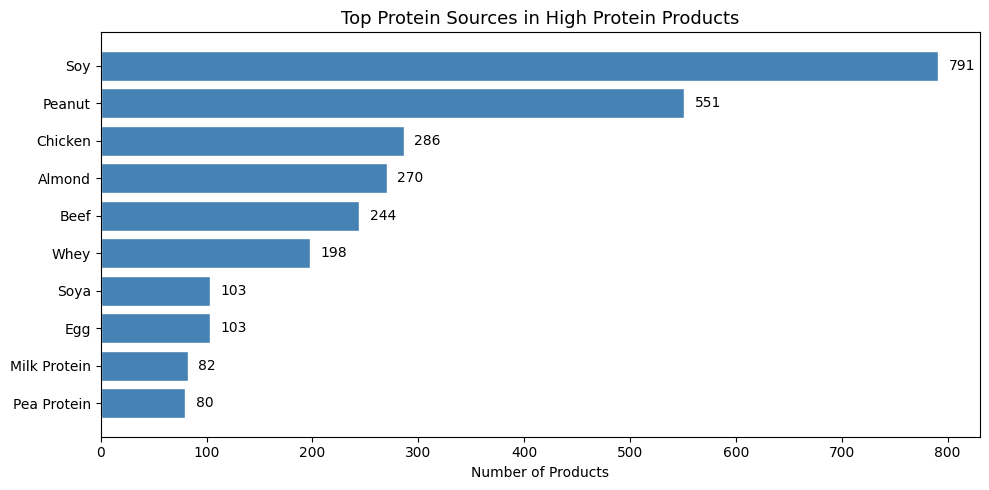

Chart saved as top_protein_sources.png


In [40]:
figure, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    ingredient_df.head(10)['protein_source'].str.title(),
    ingredient_df.head(10)['product_count'],
    color='steelblue',
    edgecolor='white'
)

# Add value labels on bars
for bar, val in zip(bars, ingredient_df.head(10)['product_count']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Number of Products')
ax.set_title('Top Protein Sources in High Protein Products', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('top_protein_sources.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as top_protein_sources.png")

###**6. The "Candidate's Choice" Challenge**

In [41]:
def health_score(row):
    """
    Composite score 0-100 based on WHO dietary guidelines:
    - Rewards: high protein, high fiber
    - Penalizes: high sugar, high fat
    """
    sugar_pen   = min(row['sugars_100g']  / 10, 5)
    fat_pen     = min(row['fat_100g']     / 15, 5)
    protein_rew = min(row['proteins_100g'] / 5,  5)
    fiber_rew   = min(row['fiber_100g']   / 3,   5)

    raw = (protein_rew + fiber_rew - sugar_pen - fat_pen)
    return int(round((raw + 10) * 5))

food_df['health_score'] = food_df.apply(health_score, axis=1)

print("Health Score stats:")
print(food_df['health_score'].describe().round(2))

Health Score stats:
count    80707.00
mean        53.07
std         13.34
min          3.00
25%         46.00
50%         54.00
75%         61.00
max        100.00
Name: health_score, dtype: float64


In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ['sugars_100g', 'proteins_100g', 'fat_100g', 'fiber_100g']
cluster_df = food_df[features].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df['cluster'] = kmeans.fit_predict(X_scaled)

df_clustered = df.loc[cluster_df.index].copy()
df_clustered['cluster'] = cluster_df['cluster']

#bring health_score in from food_df
df_clustered['health_score'] = food_df.loc[cluster_df.index, 'health_score']

#Confirm columns exist before groupby
print("Columns available:", df_clustered.columns.tolist())

cluster_profiles = df_clustered.groupby('cluster').agg(
    avg_sugar   = ('sugars_100g',   'mean'),
    avg_protein = ('proteins_100g', 'mean'),
    avg_fiber   = ('fiber_100g',    'mean'),
    avg_fat     = ('fat_100g',      'mean'),
    avg_health  = ('health_score',  'mean'),
    count       = ('product_name',  'count')
).round(2)

print("\nCluster Profiles:")
print(cluster_profiles.sort_values('avg_health', ascending=False))

Columns available: ['code', 'url', 'creator', 'created_t', 'created_datetime', 'last_modified_t', 'last_modified_datetime', 'last_modified_by', 'last_updated_t', 'last_updated_datetime', 'product_name', 'abbreviated_product_name', 'generic_name', 'quantity', 'packaging', 'packaging_tags', 'packaging_en', 'packaging_text', 'brands', 'brands_tags', 'brands_en', 'categories', 'categories_tags', 'categories_en', 'origins', 'origins_tags', 'origins_en', 'manufacturing_places', 'manufacturing_places_tags', 'labels', 'labels_tags', 'labels_en', 'emb_codes', 'emb_codes_tags', 'first_packaging_code_geo', 'cities', 'cities_tags', 'purchase_places', 'stores', 'countries', 'countries_tags', 'countries_en', 'ingredients_text', 'ingredients_tags', 'ingredients_analysis_tags', 'allergens', 'allergens_en', 'traces', 'traces_tags', 'traces_en', 'serving_size', 'serving_quantity', 'no_nutrition_data', 'additives_n', 'additives', 'additives_tags', 'additives_en', 'nutriscore_score', 'nutriscore_grade', '

In [43]:
sorted_clusters = (
    cluster_profiles['avg_health']
    .sort_values(ascending=False)
    .index.tolist()
)

tier_map = {
    sorted_clusters[0]: 'Tier 1 — Optimal',
    sorted_clusters[1]: 'Tier 2 — Good',
    sorted_clusters[2]: 'Tier 3 — Moderate',
    sorted_clusters[3]: 'Tier 4 — Poor'
}

df_clustered['health_tier'] = df_clustered['cluster'].map(tier_map)

print("Health Tier distribution:")
print(df_clustered['health_tier'].value_counts())

print("\nTier mapping confirmed:")
for cluster, tier in tier_map.items():
    row = cluster_profiles.loc[cluster]
    print(f"  {tier:<25} : cluster {cluster} "
          f"| health score: {row['avg_health']} "
          f"| protein: {row['avg_protein']}g "
          f"| sugar: {row['avg_sugar']}g "
          f"| count: {int(row['count']):,}")

Health Tier distribution:
health_tier
Tier 3 — Moderate    53076
Tier 4 — Poor        13345
Tier 2 — Good        12771
Tier 1 — Optimal      1515
Name: count, dtype: int64

Tier mapping confirmed:
  Tier 1 — Optimal          : cluster 0 | health score: 81.84 | protein: 16.74g | sugar: 8.73g | count: 1,515
  Tier 2 — Good             : cluster 1 | health score: 58.59 | protein: 20.37g | sugar: 4.72g | count: 12,771
  Tier 3 — Moderate         : cluster 3 | health score: 55.69 | protein: 6.66g | sugar: 5.47g | count: 53,076
  Tier 4 — Poor             : cluster 2 | health score: 34.06 | protein: 4.71g | sugar: 45.38g | count: 13,345


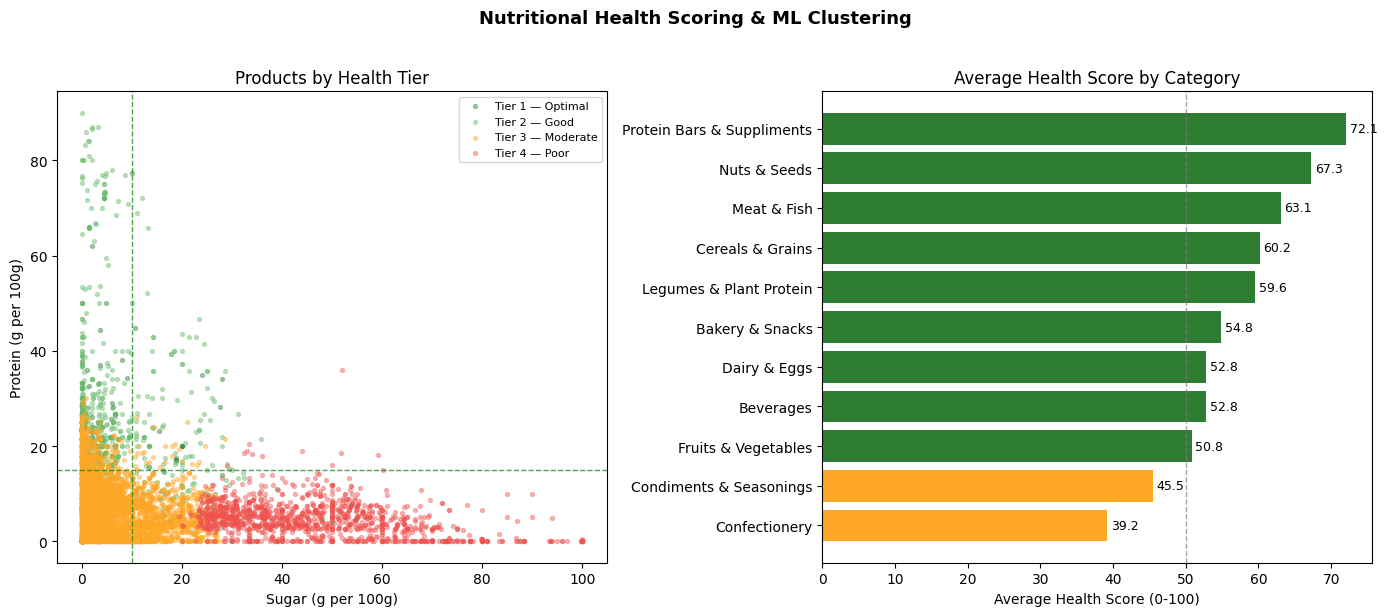

Chart saved as health_clustering.png


In [44]:
colors = {
    'Tier 1 — Optimal'  : '#2E7D32',
    'Tier 2 — Good'     : '#66BB6A',
    'Tier 3 — Moderate' : '#FFA726',
    'Tier 4 — Poor'     : '#EF5350'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Plot 1: Scatter colored by health tier
sample = df_clustered.sample(8000, random_state=42)

for tier, color in colors.items():
    mask = sample['health_tier'] == tier
    axes[0].scatter(
        sample.loc[mask, 'sugars_100g'],
        sample.loc[mask, 'proteins_100g'],
        c=color, alpha=0.4, s=8, label=tier
    )

axes[0].axvline(x=10, color='green', linestyle='--', linewidth=1, alpha=0.7)
axes[0].axhline(y=15, color='green', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Sugar (g per 100g)')
axes[0].set_ylabel('Protein (g per 100g)')
axes[0].set_title('Products by Health Tier')
axes[0].legend(loc='upper right', fontsize=8)

# Add primary_category to df_clustered
df_clustered['primary_category'] = food_df.loc[cluster_df.index, 'primary_category']

#Plot 2: Average health score by category
cat_scores = (
    df_clustered[df_clustered['primary_category'] != 'Other']
    .groupby('primary_category')['health_score']
    .mean()
    .sort_values(ascending=True)
)

bars = axes[1].barh(
    cat_scores.index,
    cat_scores.values,
    color=['#2E7D32' if v >= 50 else '#FFA726' if v >= 35 else '#EF5350'
           for v in cat_scores.values]
)

axes[1].axvline(x=50, color='gray', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_xlabel('Average Health Score (0-100)')
axes[1].set_title('Average Health Score by Category')

for bar, val in zip(bars, cat_scores.values):
    axes[1].text(bar.get_width() + 0.5,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

plt.suptitle("Nutritional Health Scoring & ML Clustering",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('health_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as health_clustering.png")